In [19]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import matplotlib.pyplot as plt

In [20]:
file_path = r"D:\\paper\\C\\data\\ex\\Final.csv"


      # تنظیم نمایش برای نمایش تمام ستون‌ها
pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', 45) # یا هر عدد بسیار بزرگی که فکر می‌کنید فایل شما از آن کمتر است

        # همچنین می‌توانید تعداد کاراکترهای نمایش داده شده در هر ستون را افزایش دهید
pd.set_option('display.max_colwidth', None)


df = pd.read_csv(file_path) # خواندن فایل اکسل

print(df.head())

   Gas real(MJ)22 ((بازده 50%)  20 ta 28 , all consumes
0                  52140.44803               45133.2465
1                  42831.43469               33076.5133
2                  28337.27086               32703.0327
3                  28238.15871               32648.1578
4                  43870.08423               42814.1451


In [21]:
# تعریف دیکشنری نگاشت نام ستون‌های قدیمی به نام ستون‌های جدید
# مثال: 'نام ستون قدیمی ۱': 'نام ستون جدید ۱', 'نام ستون قدیمی ۲': 'نام ستون جدید ۲'
new_column_names = {
    'Gas real(MJ)22 ((بازده 50%)': 'bills',
    '20 ta 28 , all consumes': 'simulations'}

# تغییر نام ستون‌ها با استفاده از متد .rename()
# inplace=True به این معنی است که تغییرات مستقیماً روی DataFrame اصلی اعمال می‌شود
df.rename(columns=new_column_names, inplace=True)
print(df.head())

         bills  simulations
0  52140.44803   45133.2465
1  42831.43469   33076.5133
2  28337.27086   32703.0327
3  28238.15871   32648.1578
4  43870.08423   42814.1451


In [22]:


# ایجاد یک نمونه از MinMaxScaler
scaler = MinMaxScaler()

numerical_features = ['bills', 'simulations']
# اعمال مقیاس‌بندی فقط روی ستون‌های عددی
# .values برای تبدیل DataFrame یا Series به آرایه NumPy است که scikit-learn نیاز دارد
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# نمایش DataFrame مقیاس‌بندی شده
print("\nDataFrame پس از اعمال MinMaxScaler:")
print(df)



DataFrame پس از اعمال MinMaxScaler:
       bills  simulations
0   0.717279     1.000000
1   0.548660     0.034309
2   0.286120     0.004395
3   0.284325     0.000000
4   0.567474     0.814250
5   0.706885     0.983553
6   0.606584     0.035223
7   0.389640     0.037289
8   0.445258     0.033326
9   0.736226     0.798002
10  1.000000     0.976939
11  0.805454     0.001345
12  0.392686     0.080304
13  0.359919     0.049614
14  0.614101     0.800250
15  0.777746     0.919721
16  0.602921     0.003363
17  0.195200     0.088686
18  0.373065     0.048507
19  0.765257     0.818614
20  0.691938     0.909760
21  0.589827     0.060888
22  0.253136     0.102701
23  0.000000     0.025102
24  0.293403     0.804535
25  0.656419     0.950740
26  0.632628     0.060039
27  0.358283     0.102394
28  0.314049     0.009025
29  0.606220     0.785094
30  0.624855     0.982611
31  0.553638     0.023450
32  0.412052     0.049031
33  0.371080     0.002967
34  0.650130     0.789387
35  0.766630     0.993859
3

In [23]:
#اموزش مدل


from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor # از Regressor استفاده می‌کنیم
from sklearn.metrics import mean_squared_error, r2_score # معیارهای ارزیابی برای رگرسیون
import numpy as np

# --- حالا از نام ستون‌های مقیاس‌بندی شده برای فیچر و تارگت استفاده می‌کنیم ---

# تعریف نام ستون‌های فیچر (که اکنون مقیاس‌بندی شده‌اند)
# شما می‌توانید لیستی از نام ستون‌ها را اینجا قرار دهید اگر بیش از یک فیچر دارید
feature_columns = ['bills']

# تعریف نام ستون تارگت
target_column = 'simulations' # نام ستون هدف خودتان را اینجا قرار دهید

# استخراج فیچرها و تارگت از DataFrame
# از `[[...]]` استفاده می‌کنیم تا مطمئن شویم خروجی همچنان DataFrame است
features = df[feature_columns]
target = df[[target_column]]



# تقسیم داده‌ها به مجموعه آموزش (80%) و آزمون (20%)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# تعریف و آموزش مدل KNeighborsRegressor
# n_neighbors=5 یعنی برای هر نقطه، 5 همسایه نزدیکش رو در نظر می‌گیره.
knn_regressor = KNeighborsRegressor(n_neighbors=11)
knn_regressor.fit(X_train, y_train)

# پیش‌بینی روی داده‌های آزمون
y_pred = knn_regressor.predict(X_test)

# محاسبه معیارهای ارزیابی برای رگرسیون
# Mean Squared Error (MSE): میانگین مربعات خطا. مقدار کمتر بهتر است.
mse = mean_squared_error(y_test, y_pred)
# Root Mean Squared Error (RMSE): ریشه دوم MSE. تفسیر آن راحت‌تر است چون واحد خطا با واحد خروجی یکی است.
rmse = np.sqrt(mse)
# R-squared (R²): ضریب تعیین. نشان می‌دهد چه نسبتی از واریانس متغیر هدف توسط مدل توضیح داده می‌شود. مقدار نزدیک به 1 بهتر است.
r2 = r2_score(y_test, y_pred)

# نمایش نتایج
print(f"میانگین مربعات خطا (MSE): {mse:.4f}")
print(f"ریشه میانگین مربعات خطا (RMSE): {rmse:.4f}")
print(f"ضریب تعیین (R-squared): {r2:.4f}")

print("\nپیش‌بینی‌های مدل برای مجموعه آزمون:")
print(y_pred)
print("\nمقادیر واقعی برای مجموعه آزمون:")
print(y_test)


میانگین مربعات خطا (MSE): 0.0689
ریشه میانگین مربعات خطا (RMSE): 0.2625
ضریب تعیین (R-squared): 0.6158

پیش‌بینی‌های مدل برای مجموعه آزمون:
[[0.64983002]
 [0.64983002]
 [0.49162618]
 [0.17879226]
 [0.73076973]
 [0.17879226]
 [0.40533134]
 [0.18952513]
 [0.19454319]]

مقادیر واقعی برای مجموعه آزمون:
    simulations
39     0.814250
25     0.950740
26     0.060039
43     0.033326
35     0.993859
41     0.035223
4      0.814250
12     0.080304
8      0.033326


In [24]:
# 1. ایمپورت کردن مدل KNN Regressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# فرض می‌کنیم X_train, X_test, y_train, y_test از قبل تعریف شده‌اند
# اگر این کد را در یک سلول جدید اجرا می‌کنید، مطمئن شوید که این متغیرها در دسترس هستند.
# برای مثال:
# feature_columns = ['bills']
# target_column = 'simulations'
# features = df[feature_columns]
# target = df[[target_column]]
# X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


# 2. ایجاد نمونه از مدل KNN Regressor
# می‌توانید n_neighbors را تغییر دهید. با 5 شروع می‌کنیم.
knn_regressor = KNeighborsRegressor(n_neighbors=11)

# 3. آموزش مدل
print("در حال آموزش مدل...")
knn_regressor.fit(X_train, y_train)
print("آموزش مدل کامل شد.")

# 4. پیش‌بینی با استفاده از داده‌های تست
print("در حال انجام پیش‌بینی روی داده‌های تست...")
y_pred = knn_regressor.predict(X_test)
print("پیش‌بینی کامل شد.")

# 5. ارزیابی مدل
print("\nارزیابی مدل:")

# محاسبه MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# محاسبه RMSE
# اگر MSE منفی شد، مشکل از داده‌هاست. RMSE همیشه مثبت است.
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# محاسبه R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2 Score): {r2:.4f}")

# تفسیر نتایج:
# - MSE و RMSE: هرچه این مقادیر کمتر باشند، مدل بهتر عمل کرده است. این مقادیر نشان‌دهنده میانگین خطای پیش‌بینی مدل هستند.
# - R-squared: مقداری بین 0 و 1 است. هرچه به 1 نزدیک‌تر باشد، مدل بهتر توانسته واریانس داده‌های تارگت را توضیح دهد. مقدار 0.8 یعنی 80% از تغییرات در 'simulations' توسط 'bills' توضیح داده می‌شود.


در حال آموزش مدل...
آموزش مدل کامل شد.
در حال انجام پیش‌بینی روی داده‌های تست...
پیش‌بینی کامل شد.

ارزیابی مدل:
Mean Squared Error (MSE): 0.0689
Root Mean Squared Error (RMSE): 0.2625
R-squared (R2 Score): 0.6158


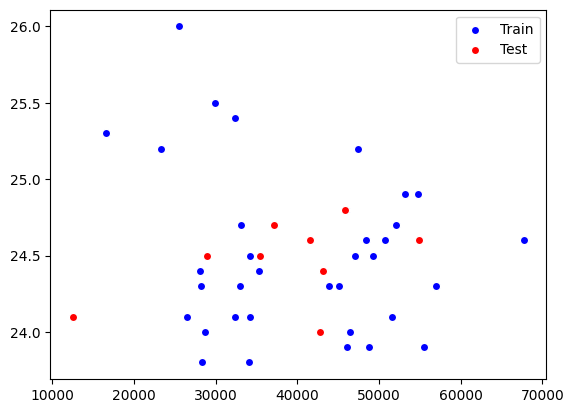

In [45]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
x = np.array([52140.4,
42831.4,
28337.3,
28238.2,
43870.1,
51566.6,
46029.2,
34052.4,
37122.9,
53186.4,
67748.7,
57008.3,
34220.5,
32411.5,
46444.2,
55478.6,
45827.0,
23317.8,
33137.3,
54789.2,
50741.4,
45104.1,
26516.3,
12541.3,
28739.4,
48780.5,
47467.1,
32321.2,
29879.1,
46009.1,
47037.9,
43106.2,
35289.6,
33027.7,
48433.3,
54865.0,
41557.5,
28894.2,
35475.4,
49261.5,
34153.9,
28032.5,
16639.7,
25527.6,
31261.9
])
y = np.array([24.7, 24, 23.8, 24.3, 24.3, 24.1, 23.9, 23.8, 24.7, 24.9, 24.6, 24.3, 24.1, 24.1, 24, 23.9, 24.8, 25.2, 24.7, 24.9, 24.6, 24.3, 24.1, 24.1, 24, 23.9, 25.2, 25.4, 25.5, 24.8, 24.5, 24.4, 24.4, 24.3, 24.6, 24.6, 24.6, 24.5, 24.5, 24.5, 24.5, 24.4, 25.3, 26, 25.9, 25.6, 25, 24.9, 24.8, 24.7, 25.3, 24.9, 23.9, 23.9, 24, 24.3, 23.5, 23.2, 23.1, 23, 24, 24, 24.3, 24.7, 24.6, 23.4, 23.3, 23.3, 23.7, 23.3, 23.3, 23.7, 23, 22.8, 22.7, 22.6, 23.5, 23.5, 23.6, 23.1, 22.9, 22.7, 22.6, 22.5, 23.1, 23.3])

idx = np.arange(44)
np.random.shuffle(idx)

#??train
train_idx = idx[:35]
val_idx = idx[35:]

x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

plt.scatter(x_train, y_train, c='b', edgecolors='w', label='Train')
plt.scatter(x_val, y_val, c='r', edgecolors='w', label='Test')
plt.legend()
plt.show()



In [47]:
#Scikit-Learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#فراخوانی داده
housing = fetch_california_housing() 
x_train, x_test, y_train, y_test = train_test_split(housing.data, housing.target) 
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.25)
#به میانگین صفر و انحراف معیار یک استاندارد می‌کنیم
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform(x_test)

model = keras.models.Sequential([keras.layers.Dense(30, activation="relu", input_shape=x_train.shape[1:]),
keras.layers.Dense(1)])


model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

ModuleNotFoundError: No module named 'sklearn.externals.joblib'

In [12]:
# اگر قبلاً کتابخانه‌های لازم را ایمپورت نکرده‌اید:
# pip install matplotlib arabic_reshaper python-bidi
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
import numpy as np

# فرض می‌کنیم X_train, X_test, y_train, y_test و y_pred از قبل تعریف شده‌اند.
# همچنین فرض می‌کنیم از مقیاس‌بندی داده‌ها استفاده کرده‌اید و X_test و y_test به مقیاس اصلی برگردانده شده‌اند،
# یا اگر مدل روی داده‌های مقیاس‌بندی شده آموزش دیده، پیش‌بینی‌ها را به مقیاس اصلی برگردانده‌اید.
# اگر این کار را نکرده‌اید، باید قبل از رسم، داده‌ها را به مقیاس اصلی برگردانید.

# برای نمایش بهتر نمودار، بهتر است داده‌های تست را به صورت مرتب شده بر اساس فیچر نمایش دهیم.
# این کار باعث می‌شود خط رگرسیون به درستی دیده شود.
# ابتدا داده‌های X_test و y_test و y_pred را با هم ترکیب کرده و مرتب می‌کنیم.

# ترکیب داده‌ها
plot_data = pd.DataFrame({'bills': X_test.iloc[:, 0], 'simulations_actual': y_test.iloc[:, 0], 'simulations_predicted': y_pred})
plot_data = plot_data.sort_values(by='bills')

# تابع کمکی برای فارسی کردن متن نمودار
def format_arabic(text):
    return get_display(arabic_reshaper.reshape(text))

# --- رسم نمودار ---
plt.figure(figsize=(12, 7))

# 1. رسم نقاط داده واقعی (Scatter plot)
plt.scatter(plot_data['bills'], plot_data['simulations_actual'], color='blue', label=format_arabic('داده‌های واقعی'), alpha=0.6)

# 2. رسم خط رگرسیون پیش‌بینی شده
plt.plot(plot_data['bills'], plot_data['simulations_predicted'], color='red', linewidth=2, label=format_arabic('خط رگرسیون پیش‌بینی شده'))

# تنظیم عنوان و برچسب‌ها با متن فارسی
plt.title(format_arabic('مقایسه داده‌های واقعی و پیش‌بینی رگرسیون KNN'), fontsize=16)
plt.xlabel(format_arabic('تعداد قبض‌ها (Bills)'), fontsize=12)
plt.ylabel(format_arabic('تعداد شبیه‌سازی‌ها (Simulations)'), fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# نمایش نمودار
plt.show()


ModuleNotFoundError: No module named 'arabic_reshaper'